In [74]:
import pandas as pd
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [50]:
cancer_comb = load_breast_cancer()
cancer_d = cancer_comb.data
cancer_t = cancer_comb.target
cancer_fn = cancer_comb.feature_names
cancer_tn = cancer_comb.target_names
df = pd.DataFrame(cancer_d, columns=cancer_fn)
df["condition"] = cancer_t
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,condition
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [51]:
print(cancer_comb.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [52]:
inf = df["condition"].value_counts()
tit = inf.index
inf

condition
1    357
0    212
Name: count, dtype: int64

In [53]:
dmap = {0:"Malignant",1:"Benign"}
df["class"] = df["condition"].map(dmap)
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,condition,class
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0,Malignant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0,Malignant
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0,Malignant
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0,Malignant
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0,Malignant


In [54]:
scaler = StandardScaler()
cancer_sc = scaler.fit_transform(cancer_d)

In [55]:
np.random.seed(42) 
noise_factor = 0.5
noisy_c = cancer_sc + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=cancer_d.shape)

sf = pd.DataFrame(cancer_sc, columns=cancer_fn)
sf_noisy = pd.DataFrame(noisy_c, columns=cancer_fn)

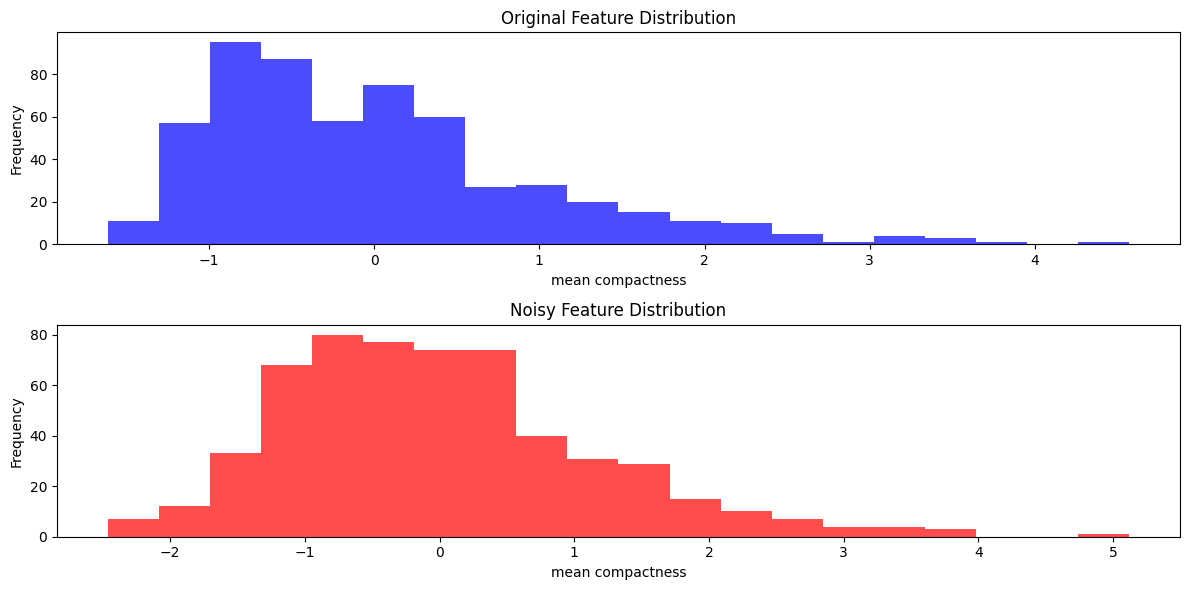

In [64]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.hist(sf[cancer_fn[5]], bins=20, alpha=.7, color='blue', label='Original')
plt.title('Original Feature Distribution')
plt.xlabel(cancer_fn[5])
plt.ylabel('Frequency')

plt.subplot(2, 1, 2)
plt.hist(sf_noisy[cancer_fn[5]], bins=20, alpha=0.7, color='red', label='Noisy') 
plt.title('Noisy Feature Distribution')
plt.xlabel(cancer_fn[5])  
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

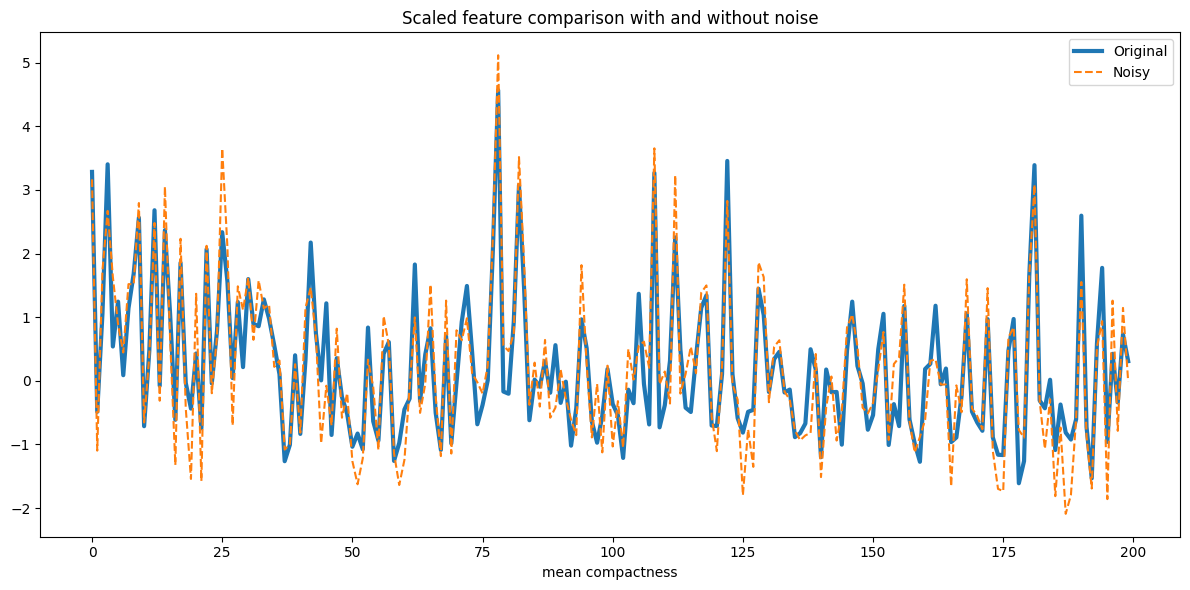

In [73]:
plt.figure(figsize=(12, 6))
plt.plot(sf[cancer_fn[5]][:200], label='Original',lw=3)
plt.plot(sf_noisy[cancer_fn[5]][:200], '--',label='Noisy',)
plt.title('Scaled feature comparison with and without noise')
plt.xlabel(cancer_fn[5])
plt.legend()
plt.tight_layout()
plt.show()

In [103]:
dat_train, dat_test, targ_train, targ_test = train_test_split(noisy_c, cancer_t, test_size=0.3,random_state=42)

svm = SVC(kernel="linear", C=1, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

svm.fit(dat_train, targ_train)
knn.fit(dat_train, targ_train)

KNeighborsClassifier()

In [105]:
pred_svm = svm.predict(dat_test)
pred_knn = knn.predict(dat_test)

print("Accuracy of SVM: %.3f" % accuracy_score(targ_test, pred_svm))
print("Accuracy of KNN: %.3f" % accuracy_score(targ_test, pred_knn))

print("\n Classification Report of SVM")
print(classification_report(targ_test, pred_svm))

print("\n Classification Report of KNN")
print(classification_report(targ_test, pred_knn))

Accuracy of SVM: 0.971
Accuracy of KNN: 0.936

 Classification Report of SVM
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        63
           1       0.98      0.97      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171


 Classification Report of KNN
              precision    recall  f1-score   support

           0       0.93      0.89      0.91        63
           1       0.94      0.96      0.95       108

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



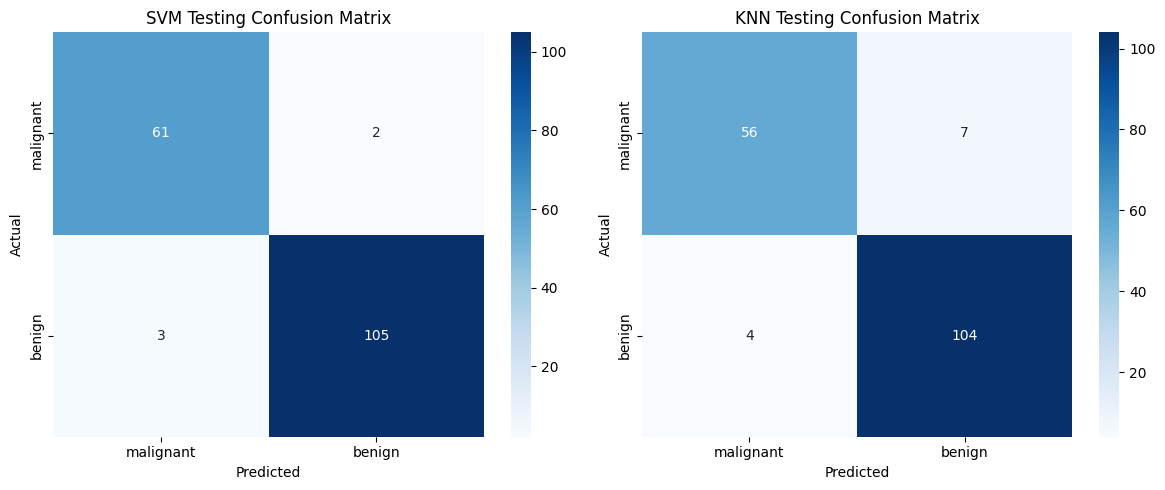

In [107]:
conf_matrix_svm = confusion_matrix(targ_test, pred_svm)
conf_matrix_knn = confusion_matrix(targ_test, pred_knn)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(conf_matrix_svm, annot=True, cmap='Blues', fmt='d', ax=axes[0],
            xticklabels=cancer_tn, yticklabels=cancer_tn)

axes[0].set_title('SVM Testing Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(conf_matrix_knn, annot=True, cmap='Blues', fmt='d', ax=axes[1],
            xticklabels=cancer_tn, yticklabels=cancer_tn)
axes[1].set_title('KNN Testing Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [109]:
train_pred_svm = svm.predict(dat_train)
train_pred_knn = knn.predict(dat_train)

In [113]:
print("Accuracy of Training Set by SVM: %.3f" %accuracy_score(targ_train, train_pred_svm))
print("Accuracy of Training Set by KNN: %.3f" %accuracy_score(targ_train, train_pred_knn))

print("\n Classification Report of SVM Training Set", "\n", classification_report(targ_train, train_pred_svm))

print("\n Classification Report of KNN Training Set", "\n", classification_report(targ_train, train_pred_knn))

Accuracy of Training Set by SVM: 0.972
Accuracy of Training Set by KNN: 0.955

 Classification Report of SVM Training Set 
               precision    recall  f1-score   support

           0       0.98      0.95      0.96       149
           1       0.97      0.99      0.98       249

    accuracy                           0.97       398
   macro avg       0.97      0.97      0.97       398
weighted avg       0.97      0.97      0.97       398


 Classification Report of KNN Training Set 
               precision    recall  f1-score   support

           0       0.96      0.91      0.94       149
           1       0.95      0.98      0.96       249

    accuracy                           0.95       398
   macro avg       0.96      0.95      0.95       398
weighted avg       0.96      0.95      0.95       398



<function matplotlib.pyplot.show(close=None, block=None)>

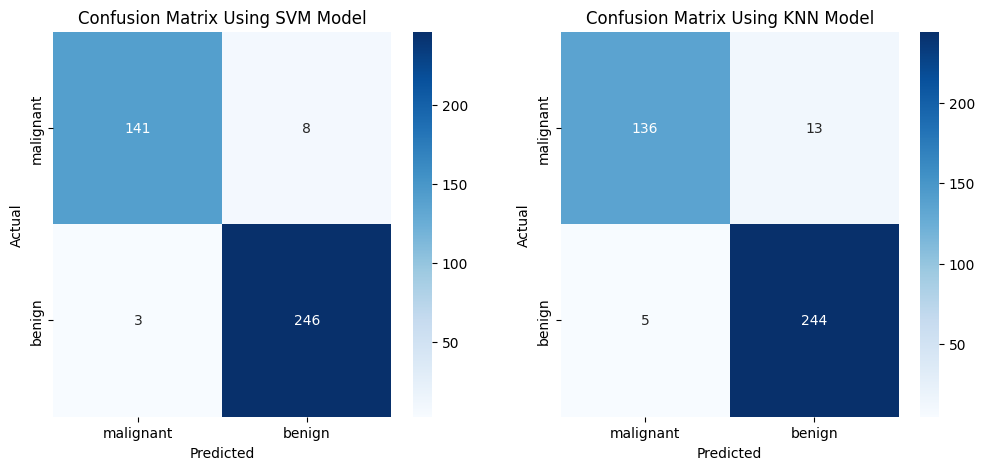

In [121]:
conf_svm = confusion_matrix(targ_train, train_pred_svm)
conf_knn = confusion_matrix(targ_train, train_pred_knn)            

fig, axis = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(conf_svm, annot=True, cmap="Blues", ax=axis[0], fmt="d", xticklabels=cancer_tn, yticklabels=cancer_tn)
axis[0].set_title("Confusion Matrix Using SVM Model")
axis[0].set_xlabel("Predicted")
axis[0].set_ylabel("Actual")

sns.heatmap(conf_knn,annot=True, cmap="Blues", ax=axis[1], fmt="d", xticklabels=cancer_tn, yticklabels=cancer_tn)
axis[1].set_title("Confusion Matrix Using KNN Model")
axis[1].set_xlabel("Predicted")
axis[1].set_ylabel("Actual")

#plt.tight_layout()
plt.show